Random Forest is used for feature selection based on feature importance values. The selected features were then used to train a Gradient Boosting Regressor for accurate RUL prediction. This hybrid approach combines robust feature selection with high predictive performance

### Importing Required Libraries and Data

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [52]:
y_true= pd.read_csv('RUL_FD001.txt',sep=r"\s+",names=["RUL"])
df_train = pd.read_csv("train_cleaned_data.csv")
df_test = pd.read_csv("test_data.csv")

In [53]:
df_train.shape, df_test.shape, y_true.shape

((20631, 20), (13096, 27), (100, 1))

In [54]:
feats = df_train.columns.drop(['UnitNumber', 'Cycle', 'RUL'])

In [55]:
df_train.head()

,UnitNumber,Cycle,OpSet1,OpSet2,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure6,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [56]:
df_test.head()

,UnitNumber,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,30
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,29
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,28
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,27
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,26


In [57]:
y_true.head()

,RUL
0,112
1,98
2,69
3,82
4,91


In [58]:
corr = df_train.corr()["RUL"].abs().sort_values(ascending=False)
top_features = corr.index[1:11]
print("Top Features Used:", top_features)

Top Features Used: Index(['Cycle', 'SensorMeasure11', 'SensorMeasure4', 'SensorMeasure12',
       'SensorMeasure7', 'SensorMeasure15', 'SensorMeasure21',
       'SensorMeasure20', 'SensorMeasure2', 'SensorMeasure17'],
      dtype='object')


In [59]:
X = df_train[top_features]
y = df_train["RUL"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
Gb_model = GradientBoostingRegressor(n_estimators=250,learning_rate=0.02,max_depth=4,random_state=42)
Gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.02
,n_estimators,250
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [61]:
y_pred = Gb_model.predict(X_test)

In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nmodel Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)


model Performance:
MAE: 26.71331689471411
MSE: 1358.27511338625
R2 Score: 0.7027060578726446


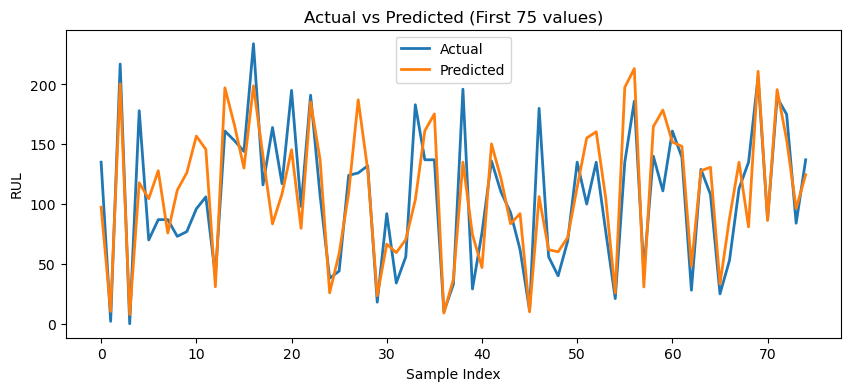

In [63]:
plt.figure(figsize=(10,4))

plt.plot(y_test.values[:75], label="Actual", linewidth=2)
plt.plot(y_pred[:75], label="Predicted", linewidth=2)

plt.xlabel("Sample Index")
plt.ylabel("RUL")
plt.title("Actual vs Predicted (First 75 values)")
plt.legend()
plt.show()


Next, we apply the XGBoost algorithm and compare its performance with existing models to identify the most accurate model for RUL prediction.

In [64]:
Xg_model = XGBRegressor(n_estimators=350,learning_rate=0.06,max_depth=5,subsample=0.8,colsample_bytree=0.8,random_state=42)

In [65]:
Xg_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [66]:
y_pred = Xg_model.predict(X_test)

In [67]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

In [68]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 26.940025329589844
MSE: 1403.104736328125
R2 Score: 0.692893922328949


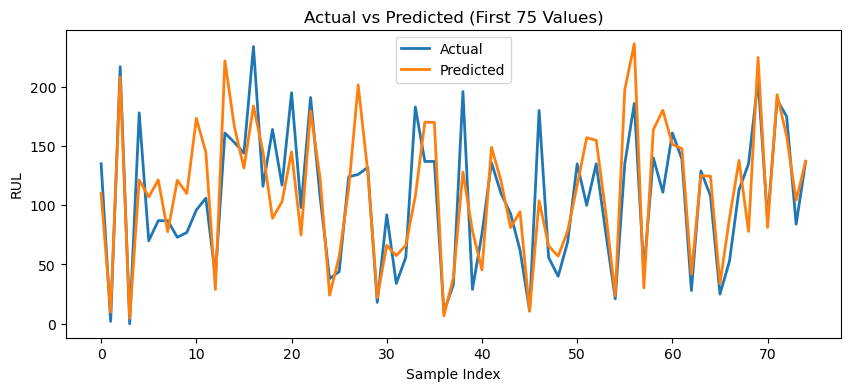

In [69]:
plt.figure(figsize=(10,4))

plt.plot(y_test.values[:75], label="Actual", linewidth=2)
plt.plot(y_pred[:75], label="Predicted", linewidth=2)

plt.xlabel("Sample Index")
plt.ylabel("RUL")
plt.title("Actual vs Predicted (First 75 Values)")
plt.legend()
plt.show()

In [70]:
input_df = pd.DataFrame([[0.9,0.3,0.6,0.4,0.55,0.45,0.2,0.8,0.5,0.4]], columns=top_features)
print(f"GB: {Gb_model.predict(input_df)[0]:.2f}, XGB: {Xg_model.predict(input_df)[0]:.2f}")

GB: 236.70, XGB: 289.06
